# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Gonzales, Naeumi
- _Student No._: 2024-11022
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->
### Problem 1: Resistor Ladder

![Voltage Distribution Line Graph for 6 internal junctions](node_voltages.png)

Figure 1. Voltage Distribution Line Graph for 6 internal junctions

![Voltage Distribution Line Graphs for different number of nodes](diff_nodes.png)

Figure 2. Voltage Distribution Line Graphs for varied number of nodes

Both graphs illustrate the way how voltage drops throughout the resistor ladder network. At each node, basis linear equations derived from Kirchhoff's Current Law were used to construct the matrix equation $A\mathbf{v} = \mathbf{w}$. Using np.linalg.solve, Figure 1 illustrates what occurs when there are six junction points. To solve the system $A\mathbf{x} = \mathbf{b}$, NumPy's np.linalg.solve(A, b) automatically employs LU decomposition via LAPACK routines, particularly _gesv. The voltage begins high near the power rail at the first two nodes (~3.8 V and ~3.6 V) and gradually drops toward 1 V by node 6, staying strictly within the anticipated range of 0 V to 5 V.

Figure 2 contrasts node counts ranging from 10 to 10,000. Mark Newman's banded function, which uses banded Gaussian elimination specifically designed for pentadiagonal matrices, was applied for $N=10,000$. It avoids the large memory and $\mathcal{O}(N^3)$ complexity of conventional solvers by removing sub-diagonals and using back-substitution in $\mathcal{O}(N)$ time. Smaller numbers of junctions cause the voltage to drop to zero in a matter of steps, initially appearing as a steep line. The voltage drop spreads out smoothly over the whole graph when the chain is stretched to 10,000 nodes, demonstrating how adding more resistors spreads out the voltage drop throughout the longer network. 

### Other comments
- None


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import banded as bd

In [50]:
N = 6

# Creating matrix A
A = np.zeros((N,N))

for i in range(N):
    
    # Main Diagonal
    if i == 0 or i == N-1:
        A[i, i] = 3
    else:
        A[i, i] = 4

    # First off-diagonals
    if i-1 >= 0:
        A[i, i-1] = -1

    if i+1 < N:
        A[i, i+1] = -1

    # Second off-diagonals
    if i-2 >= 0:
        A[i, i-2] = -1

    if i+2 < N:
        A[i, i+2] = -1

# Creating matrix w
w = np.zeros(N)
w[0] = 5
w[1] = 5

# Computing Av = w
V = np.linalg.solve(A,w)

print("A =")
print(A)

print("\nw =")
print(w)

print("\nVoltages:")
for i in range(N):
    print(f"V{i+1} = {V[i]:.6f} V")

A =
[[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]

w =
[5. 5. 0. 0. 0. 0.]

Voltages:
V1 = 3.725490 V
V2 = 3.431373 V
V3 = 2.745098 V
V4 = 2.254902 V
V5 = 1.568627 V
V6 = 1.274510 V


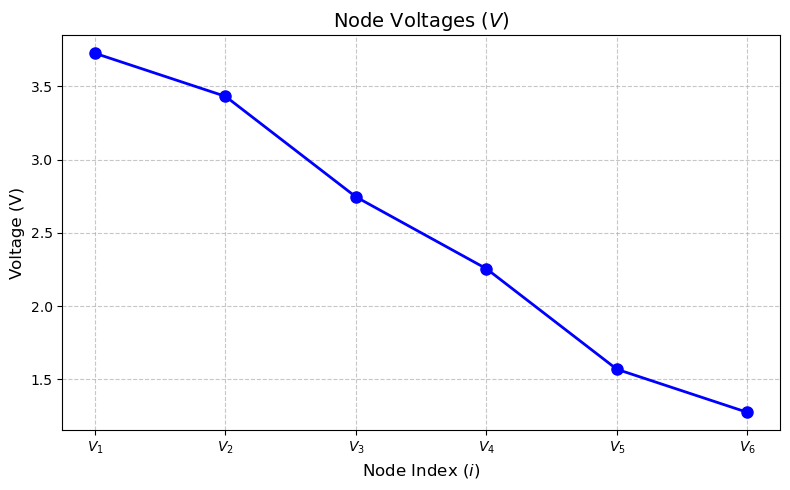

In [51]:
# Generate node indices 
node_indices = np.arange(1, len(V) + 1)

plt.figure(figsize=(8, 5))
plt.plot( node_indices, V, marker="o", linestyle="-", color="b", linewidth=2, markersize=8,)

# Labeling and Formatting
plt.title("Node Voltages ($V$)", fontsize=14)
plt.xlabel("Node Index ($i$)", fontsize=12)
plt.ylabel("Voltage (V)", fontsize=12)
plt.xticks(node_indices, [f"$V_{{{i}}}$" for i in node_indices])
plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig('node_voltages.png')
plt.show()

In [52]:
N = 10000

# Constructs the banded matrix
# 5 = 2 upper/lower diagonal + main diagonal
bd_A = np.zeros((5, N))

# Main diagonal
bd_A[2, :] = 4
bd_A[2, 0] = 3
bd_A[2, N-1] = 3

# 1st upper diagonal
bd_A[1, 1:] = -1

# 2nd upper diagonal
bd_A[0, 2:] = -1

# 1st lower diagonal
bd_A[3, :-1] = -1

# 2nd lower diagonal
bd_A[4, :-2] = -1

# right-hand side vector
bd_w = np.zeros(N)

bd_w[0] = 5
bd_w[1] = 5

# Computing AV = w
bd_V = bd.banded(bd_A, bd_w, 2, 2) 

print("V1 =", bd_V[0])
print("V2 =", bd_V[1])
print("V3 =", bd_V[2])

print("VN-2 =", bd_V[N-3])
print("VN-1 =", bd_V[N-2])
print("VN =", bd_V[N-1])

print("Minimum voltage =", bd_V.min())
print("Maximum voltage =", bd_V.max())

V1 = 4.998882277727716
V2 = 4.998618419291493
V3 = 4.9980284138916575
VN-2 = 0.001971586108334918
VN-1 = 0.0013815807085025764
VN = 0.0011177222722791647
Minimum voltage = 0.0011177222722791647
Maximum voltage = 4.998882277727716


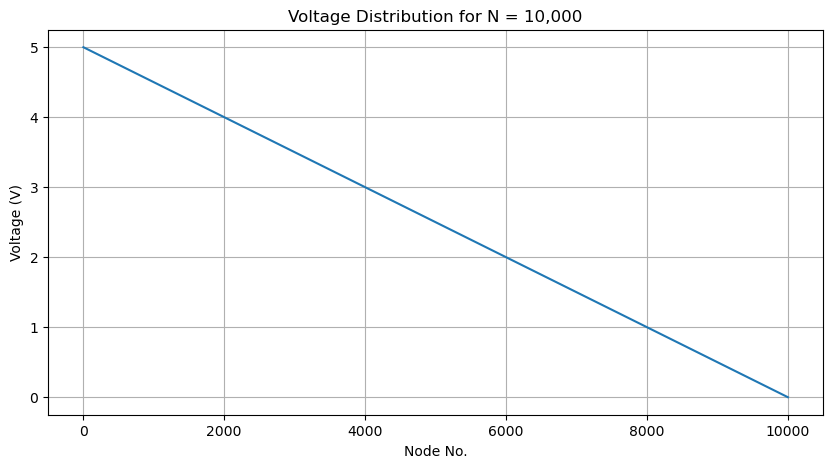

In [53]:
# Graph for N = 10,000

nodes = np.arange(1, N+1)

plt.figure(figsize=(10,5))
plt.plot(nodes, bd_V)

plt.xlabel("Node No.")
plt.ylabel("Voltage (V)")
plt.title("Voltage Distribution for N = 10,000")
plt.grid()
plt.savefig('10000_nodes.png')
plt.show()

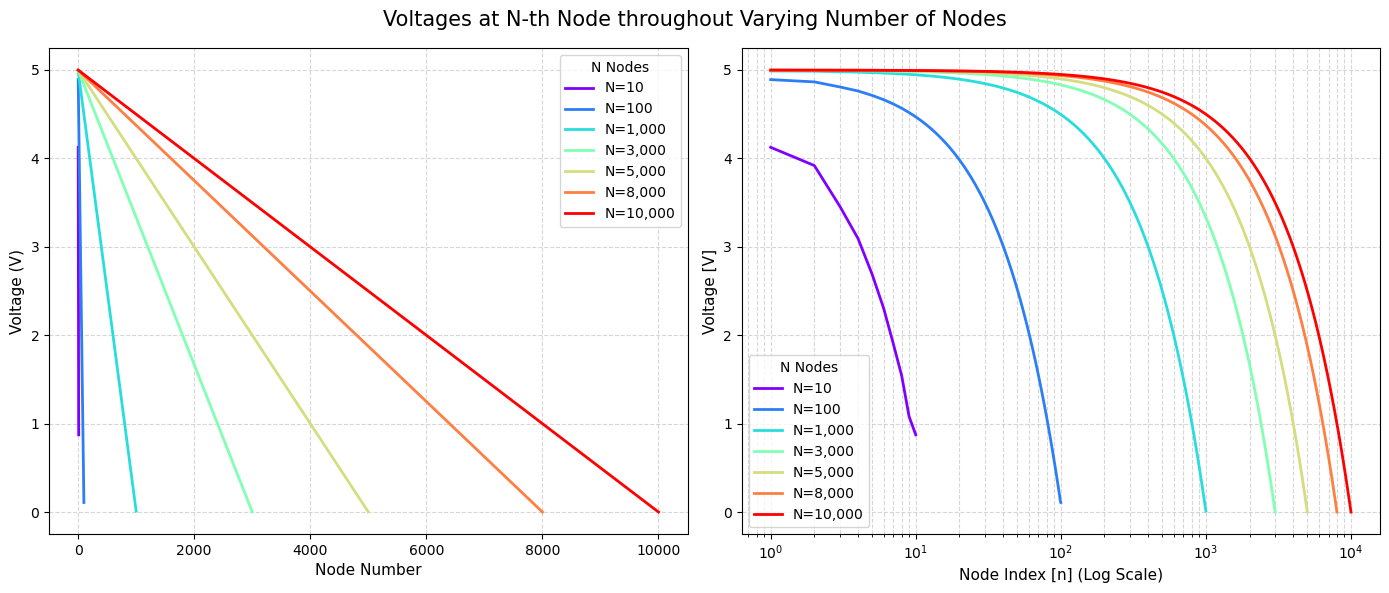

In [54]:
# List of N values to solve for
N_values = [10, 100, 1000, 3000, 5000, 8000, 10000]
V = {}

# Solve matrix system for each N
for N in N_values:
    bd_A = np.zeros((5, N))

    bd_A[2, :] = 4
    bd_A[2, 0] = 3
    bd_A[2, N - 1] = 3

    bd_A[1, 1:] = -1
    bd_A[0, 2:] = -1
    bd_A[3, :-1] = -1
    bd_A[4, :-2] = -1

    bd_w = np.zeros(N)
    bd_w[0] = 5
    bd_w[1] = 5

    V[N] = bd.banded(bd_A, bd_w, 2, 2)

#Generates a figure with 2 side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.rainbow(np.linspace(0, 1, len(N_values)))

#Linear Scale
for N, color in zip(N_values, colors):
    ax1.plot(np.arange(1, N + 1), V[N], label=f"N={N:,}", color=color, linewidth=2)

ax1.set_xlabel("Node Number", fontsize=11)
ax1.set_ylabel("Voltage (V)", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(title="N Nodes", loc="upper right")

#Semi-Logarithmic Scale
for N, color in zip(N_values, colors):
    ax2.semilogx(np.arange(1, N + 1), V[N], label=f"N={N:,}", color=color, linewidth=2)

ax2.set_xlabel("Node Index [n] (Log Scale)", fontsize=11)
ax2.set_ylabel("Voltage [V]", fontsize=11)
ax2.grid(True, which="both", linestyle="--", alpha=0.5)
ax2.legend(title="N Nodes", loc="lower left")

fig.suptitle("Voltages at N-th Node throughout Varying Number of Nodes", fontsize=15)

plt.tight_layout()
plt.savefig("diff_nodes.png", dpi=300)
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
* Standard matrix solvers are too slow and memory-intensive; thus, this code uses Kirchhoff's Current Law at each resistor ladder junction to transform the circuit into a system of linear equations. These equations are then solved using NumPy's np.linalg.solve for N = 6 and Mark Newman's banded solver for N = 10000. The pentadiagonal equations of the circuit are solved by the code using np.zeros and a compressed 5xN banded matrix. The differences are then plotted using line graphs across different numbers of nodes.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [ ]:
import samplePackage as sP

In [ ]:
sP.createZerosArray(4,5)